In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generación de 1 señal

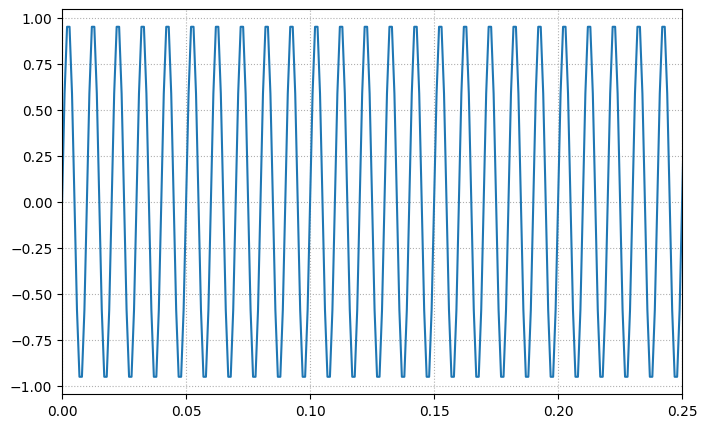

In [ ]:
def gen_sin(f, fs, t):
    w = 2*np.pi*f
    #tt = np.linspace(0, t, t*fs)
    Ts=1/fs

    time_max = t
    N = t*fs
    n = np.arange(N)

    t = n*Ts

    x = np.sin(w*t)

    return t, x


f = 100  # 50 hz
fs = 10*f
time = 4

t, x = gen_sin(f, fs, t=time)

plt.figure(figsize=(8,5))
plt.plot(t,x)
plt.grid(ls=":")
plt.xlim(0,0.25)
plt.show()

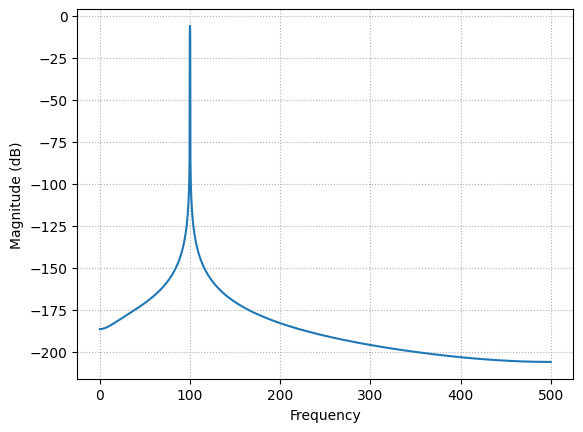

In [ ]:
plt.magnitude_spectrum(x, Fs=fs, scale='dB')
plt.grid(ls=":")
plt.show()
#

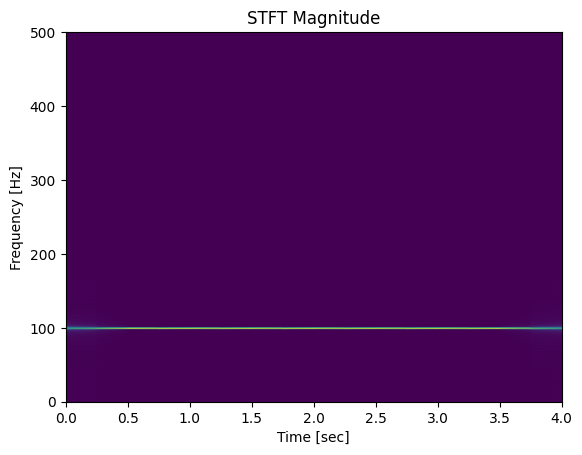

In [ ]:
from scipy import signal

f, t, Zxx = signal.stft(x, fs, nperseg=1000)
plt.pcolormesh(t, f, np.abs(Zxx), vmin=0,  shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

# Generacion de 2 señales

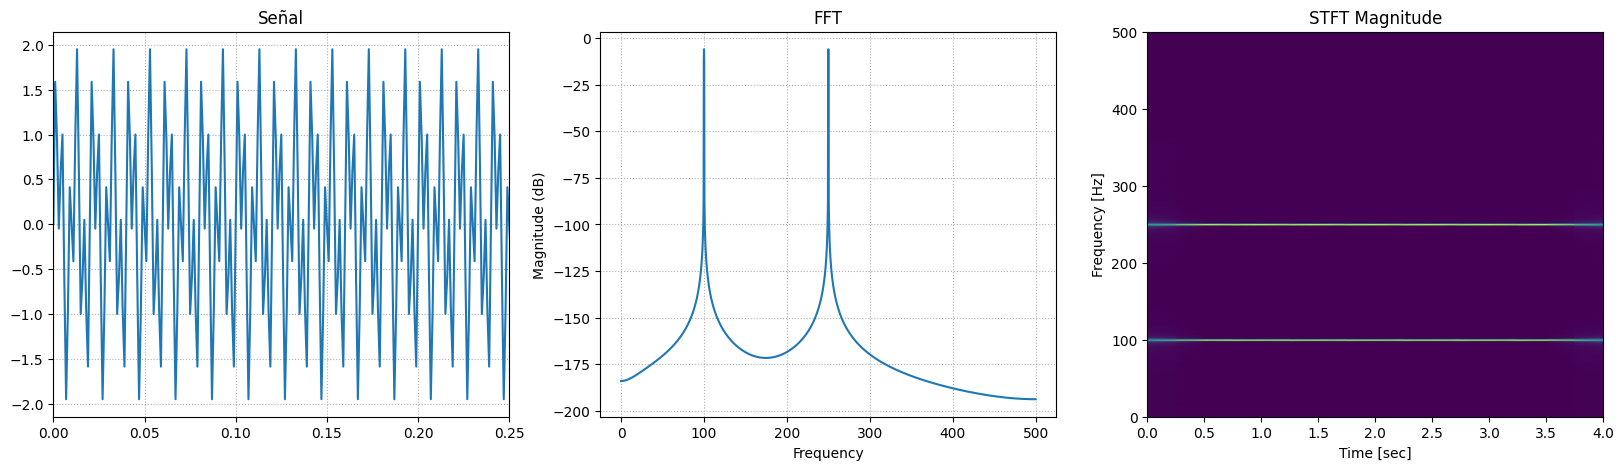

In [ ]:
f1 = 100  # 50 hz
fs = 10*f1
time = 4

f2 = 250


t, x1 = gen_sin(f=f1, fs=fs, t=time)
_, x2 = gen_sin(f=f2, fs=fs, t=time)

x = x1+x2

plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
plt.title("Señal")
plt.plot(t,x)
plt.grid(ls=":")
plt.xlim(0,0.25)

plt.subplot(1,3,2)
plt.title("FFT")
plt.magnitude_spectrum(x, Fs=fs, scale='dB')
plt.grid(ls=":")

plt.subplot(1,3,3)
f, tt, Zxx = signal.stft(x, fs, nperseg=1000)
plt.pcolormesh(tt, f, np.abs(Zxx), vmin=0,  shading='gouraud')
plt.title('STFT Magnitude')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')


plt.show()

## Aplicando un filtrado pasa bajas

✅ SOLUCIONES PROFESIONALES

🔵 1️⃣ Usar filtfilt (RECOMENDADO)

Elimina fase y reduce transitorio:

`y = signal.filtfilt(b_fir, 1, x)`


Ventajas:

- Cero fase
- Reduce artefactos iniciales
- Muy usado en biomédica

🔵 2️⃣ Recortar el transitorio

Simplemente eliminar las primeras muestras:

`delay = (numtaps - 1) // 2`

`y_corrected = y[delay:]`

`t_corrected = t[delay:]`


Esto compensa el retardo de grupo.

🔵 3️⃣ Inicializar condiciones adecuadas

Puedes calcular estado inicial:



```
zi = signal.lfilter_zi(b_fir, 1)
y, _ = signal.lfilter(b_fir, 1, x, zi=zi*x[0])
```




Esto reduce el salto inicial.

🔵 4️⃣ Añadir padding antes de filtrar


```
x_pad = np.pad(x, (numtaps, 0), mode='reflect')
y = signal.lfilter(b_fir, 1, x_pad)
y = y[numtaps:]
```




Muy usado en procesamiento offline.

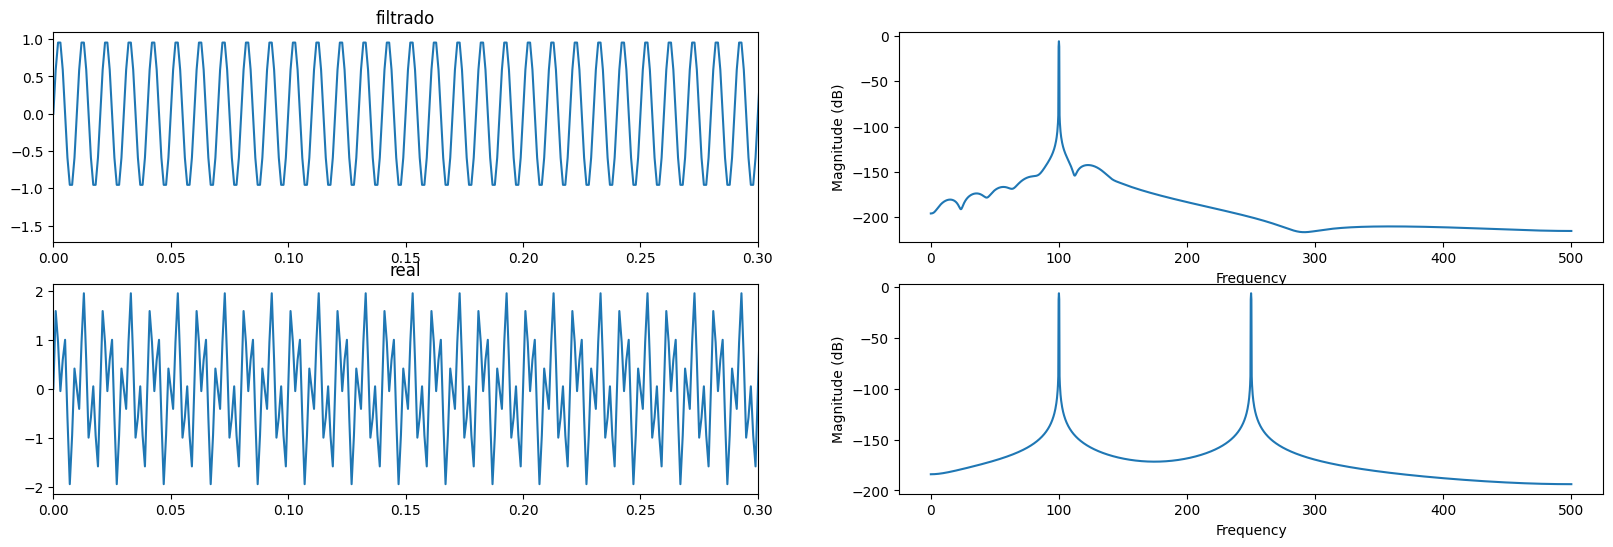

In [ ]:
"""
windows:
- boxcar
- triang
- blackman
- hamming
- hann
- bartlett
"""

numtaps=101
cutoff = 125

b_fir = signal.firwin(numtaps, cutoff, window='hann', fs=fs, pass_zero=True)

#y = signal.lfilter(b_fir, 1, x)
y = signal.filtfilt(b_fir, 1, x)

plt.figure(figsize=(20,6))

plt.subplot(2,2,1)
plt.title("filtrado")
plt.plot(t,y)
plt.xlim(0,0.3)

plt.subplot(2,2,2)
plt.magnitude_spectrum(y, Fs=fs, scale='dB')

plt.subplot(2,2,3)
plt.title("real")
plt.plot(t,x)
plt.xlim(0,0.3)

plt.subplot(2,2,4)
plt.magnitude_spectrum(x, Fs=fs, scale='dB')

plt.show()


## Filtro pasa alta

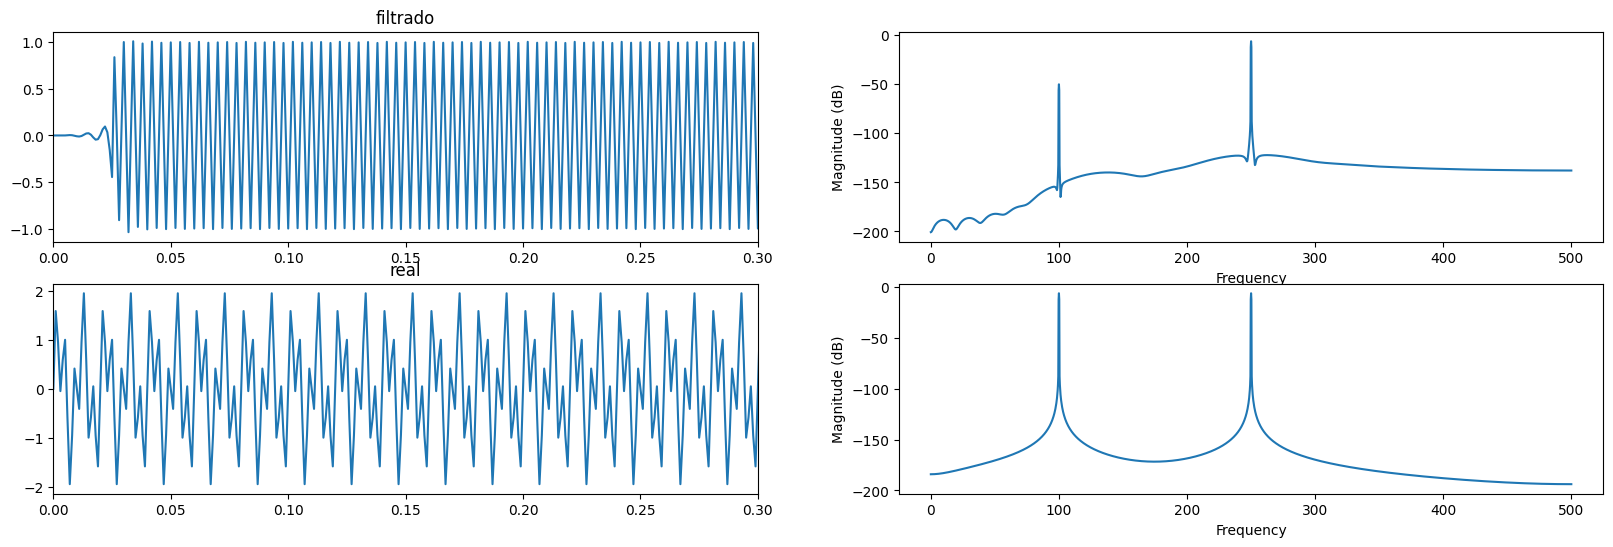

In [ ]:
"""
windows:
- boxcar
- triang
- blackman
- hamming
- hann
- bartlett
"""

numtaps=51
cutoff = 140

b_fir = signal.firwin(numtaps, cutoff, window='hann', fs=fs, pass_zero=False)

y = signal.lfilter(b_fir, 1, x)
#y = signal.filtfilt(b_fir, 1, x)

plt.figure(figsize=(20,6))

plt.subplot(2,2,1)
plt.title("filtrado")
plt.plot(t,y)
plt.xlim(0,0.3)

plt.subplot(2,2,2)
plt.magnitude_spectrum(y, Fs=fs, scale='dB')

plt.subplot(2,2,3)
plt.title("real")
plt.plot(t,x)
plt.xlim(0,0.3)

plt.subplot(2,2,4)
plt.magnitude_spectrum(x, Fs=fs, scale='dB')

plt.show()

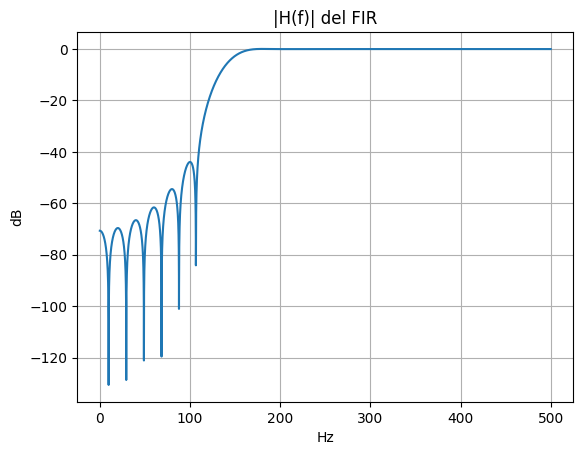

In [ ]:
w, h = signal.freqz(b_fir, [1], worN=8192, fs=fs)
Hdb = 20*np.log10(np.abs(h) + 1e-20)

plt.plot(w, Hdb)
plt.title('|H(f)| del FIR')
plt.xlabel('Hz'); plt.ylabel('dB')
plt.grid(True)
plt.show()

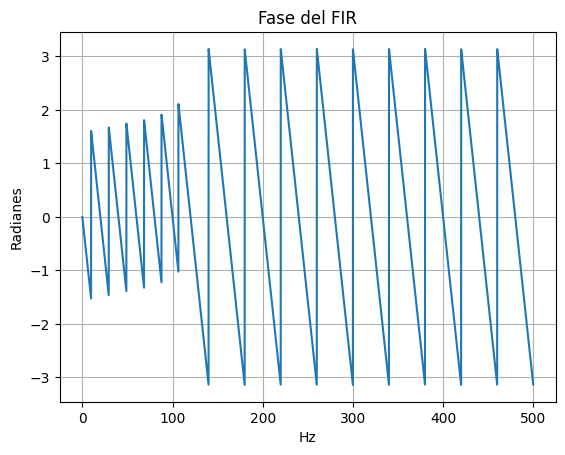

In [ ]:
w, h = signal.freqz(b_fir, [1], worN=8192, fs=fs)

phase = np.angle(h)

plt.plot(w, phase)
plt.title('Fase del FIR')
plt.xlabel('Hz')
plt.ylabel('Radianes')
plt.grid(True)
plt.show()

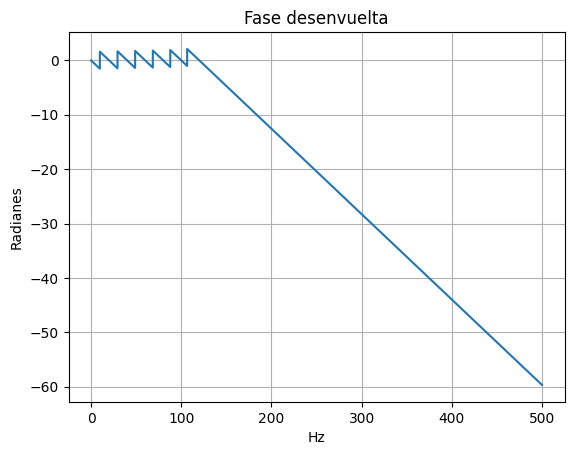

In [ ]:
phase_unwrapped = np.unwrap(np.angle(h))

plt.plot(w, phase_unwrapped)
plt.title('Fase desenvuelta')
plt.xlabel('Hz')
plt.ylabel('Radianes')
plt.grid(True)
plt.show()

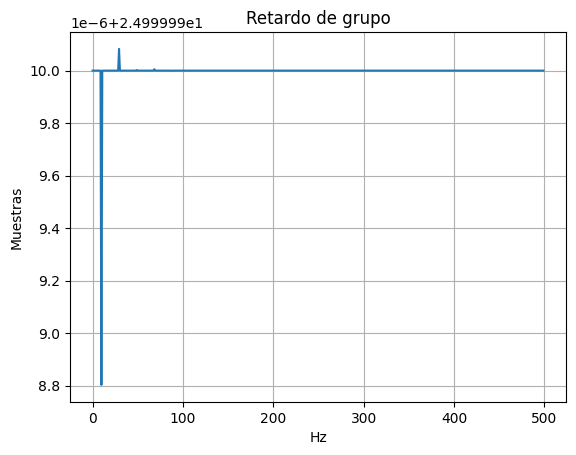

In [ ]:
w_gd, gd = signal.group_delay((b_fir, [1]), fs=fs)

plt.plot(w_gd, gd)
plt.title('Retardo de grupo')
plt.xlabel('Hz')
plt.ylabel('Muestras')
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


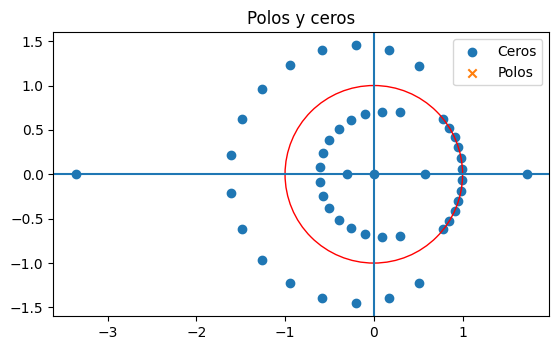

In [ ]:
z, p, k = signal.tf2zpk(b_fir, 1)

plt.scatter(np.real(z), np.imag(z), marker='o', label='Ceros')
plt.scatter(np.real(p), np.imag(p), marker='x', label='Polos')

circle = plt.Circle((0,0), 1, color='r', fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.title('Polos y ceros')
plt.show()

In [ ]:
np.all(np.abs(p) < 1)

np.True_

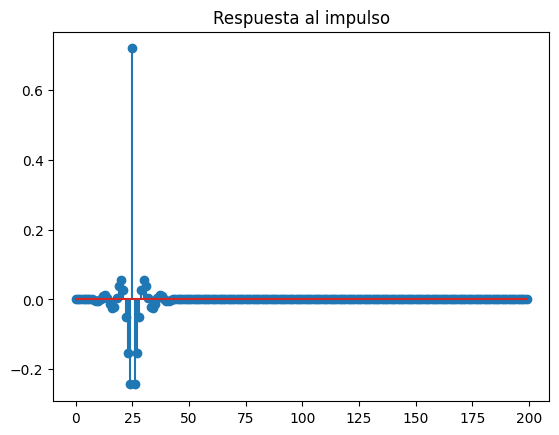

In [ ]:
imp = np.zeros(200)
imp[0] = 1

y_imp = signal.lfilter(b_fir, 1, imp)

plt.stem(y_imp)
plt.title("Respuesta al impulso")
plt.show()

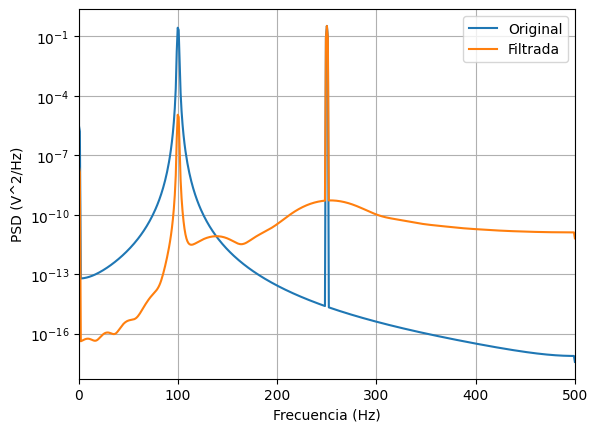

In [ ]:

f_x, Pxx = signal.welch(x, fs=fs, window='hann', nperseg=1024, noverlap=512, scaling='density')
f_y, Pyy = signal.welch(y, fs=fs, window='hann', nperseg=1024, noverlap=512, scaling='density')

plt.semilogy(f_x, Pxx, label='Original')
plt.semilogy(f_y, Pyy, label='Filtrada')
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.grid(True)
plt.legend()
plt.show()

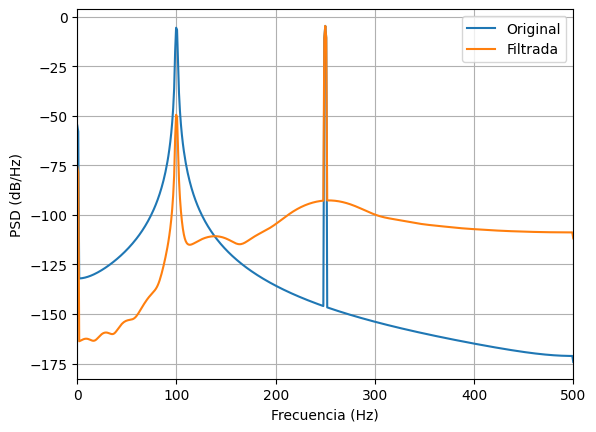

In [ ]:
plt.plot(f_x, 10*np.log10(Pxx + 1e-20), label='Original')
plt.plot(f_y, 10*np.log10(Pyy + 1e-20), label='Filtrada')
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (dB/Hz)')
plt.grid(True)
plt.legend()
plt.show()

# Filtro FIR

In [ ]:
?signal.butter

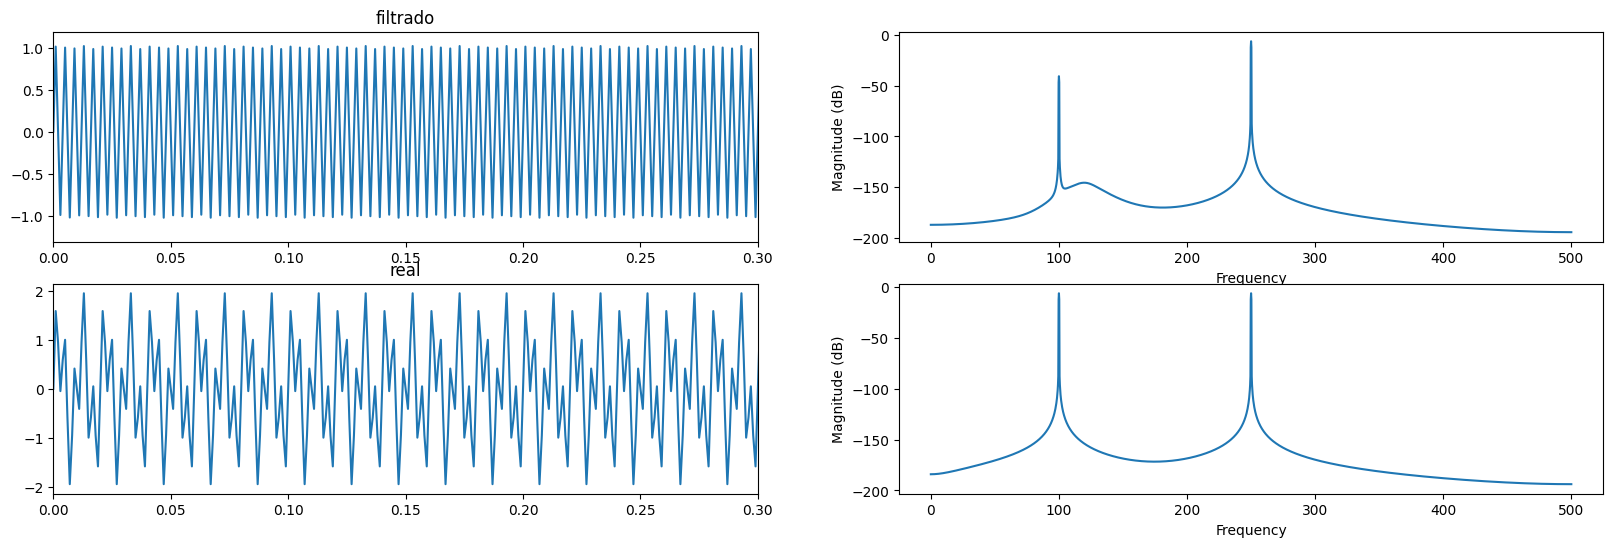

In [ ]:
fc = 120

b,a = signal.butter(10, fc,btype='highpass', fs=fs)

y = signal.filtfilt(b, a, x)

plt.figure(figsize=(20,6))

plt.subplot(2,2,1)
plt.title("filtrado")
plt.plot(t,y)
plt.xlim(0,0.3)

plt.subplot(2,2,2)
plt.magnitude_spectrum(y, Fs=fs, scale='dB')

plt.subplot(2,2,3)
plt.title("real")
plt.plot(t,x)
plt.xlim(0,0.3)

plt.subplot(2,2,4)
plt.magnitude_spectrum(x, Fs=fs, scale='dB')

plt.show()

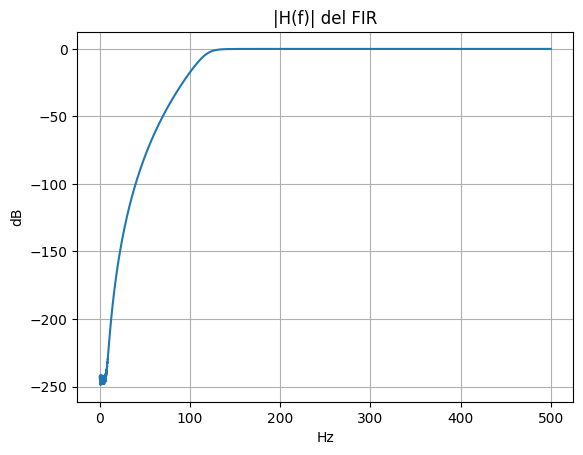

In [ ]:
w, h = signal.freqz(b, a, worN=8192, fs=fs)
Hdb = 20*np.log10(np.abs(h) + 1e-20)

plt.plot(w, Hdb)
plt.title('|H(f)| del FIR')
plt.xlabel('Hz'); plt.ylabel('dB')
plt.grid(True)
plt.show()

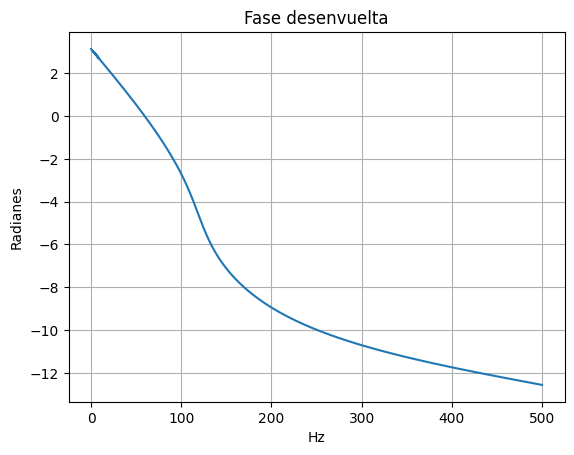

In [ ]:
phase_unwrapped = np.unwrap(np.angle(h))

plt.plot(w, phase_unwrapped)
plt.title('Fase desenvuelta')
plt.xlabel('Hz')
plt.ylabel('Radianes')
plt.grid(True)
plt.show()

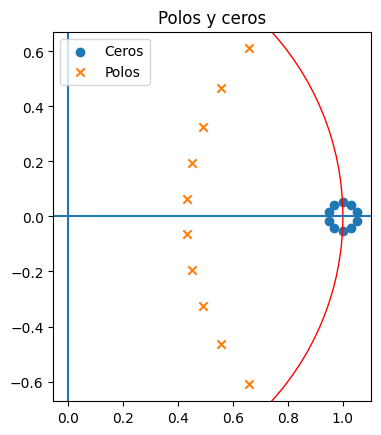

In [ ]:
z, p, k = signal.tf2zpk(b, a)

plt.scatter(np.real(z), np.imag(z), marker='o', label='Ceros')
plt.scatter(np.real(p), np.imag(p), marker='x', label='Polos')

circle = plt.Circle((0,0), 1, color='r', fill=False)
plt.gca().add_artist(circle)

plt.axhline(0)
plt.axvline(0)
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.title('Polos y ceros')
plt.show()

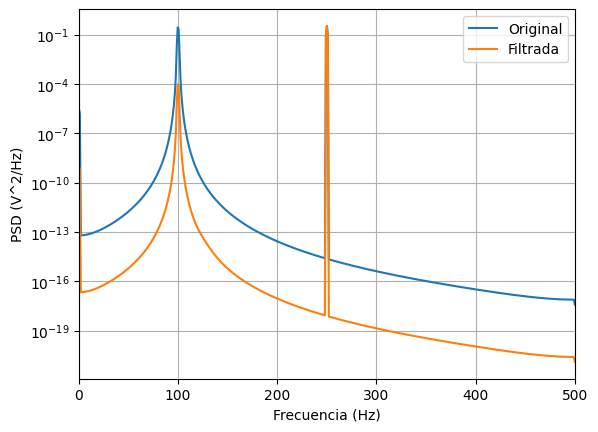

In [ ]:
f_x, Pxx = signal.welch(x, fs=fs, window='hann', nperseg=1024, noverlap=512, scaling='density')
f_y, Pyy = signal.welch(y, fs=fs, window='hann', nperseg=1024, noverlap=512, scaling='density')

plt.semilogy(f_x, Pxx, label='Original')
plt.semilogy(f_y, Pyy, label='Filtrada')
plt.xlim(0, fs/2)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.grid(True)
plt.legend()
plt.show()